# M4: HC vs. PD

`PLANbeh.md` M4: point clouds side by side, location (Hotelling T2) and shape (M2 features) comparisons -- the same battery M1/M2 already ran on every other group pair -- plus a PD-specific check: within-session click consistency, since PD's motor symptoms could plausibly show up as noisier individual clicking (more scatter around a subject's own centroid within one sitting) rather than a shifted match point, which centroid location and pooled-session shape features wouldn't cleanly separate from a real location/shape difference.

In [1]:
import sys
sys.path.append('../scripts')

import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg

import comparisons
import features
import loader
import plotting

df = loader.load_behavioral()
categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'PD', 'group': 'PD'},
]

## Point clouds, side by side

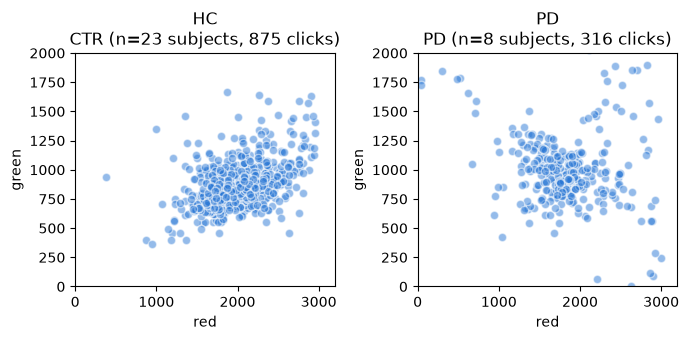

In [2]:
plotting.plot_groups_side_by_side(df, categories);

## Location: Hotelling T^2 (subject-level, M1's own convention)

In [3]:
comparisons.compare_groups(df, group1='CTR', group2='PD', unit='subject')

{'t2_stat': np.float64(26.840996483380447),
 'f_stat': np.float64(12.95772244025263),
 'p_value': np.float64(0.00011351355300001498),
 'pooled_cov': array([[21609.90825104, -2164.59361914],
        [-2164.59361914,  9999.65566066]]),
 'n1': 23,
 'n2': 8,
 'unit': 'subject'}

## Shape: PCA features (M2's own convention)

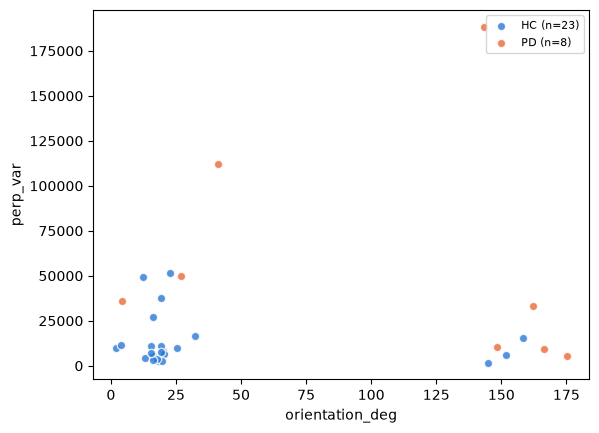

In [4]:
plotting.plot_feature_space(df, categories);

In [5]:
pd.DataFrame([
    features.compare_shape_feature(df, feat, group1='CTR', group2='PD')
    for feat in ('orientation_deg', 'along_var', 'perp_var')
])

,feature,u_val,p_value,rbc,cles,n1,n2
0,orientation_deg,33.0,0.006325,-0.641304,0.179348,23,8
1,along_var,45.0,0.033816,-0.510870,0.244565,23,8
2,perp_var,44.0,0.029912,-0.521739,0.239130,23,8


## Within-session click consistency (PD-specific)

`features.within_session_scatter`: each subject's own clicks' RMS distance to that session's centroid, averaged across sessions -- "how much does this subject's hand wander within one sitting", distinct from where they aim (location) or the overall click-cloud shape pooled across sessions (M2's features).

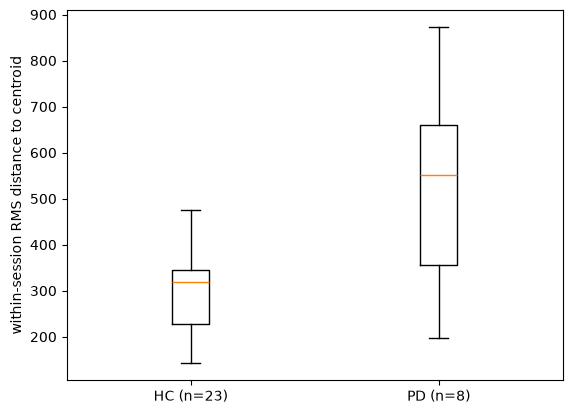

In [6]:
hc_scatter = [features.within_session_scatter(df, s) for s in loader.subjects_in_group(df, group='CTR')]
pd_scatter = [features.within_session_scatter(df, s) for s in loader.subjects_in_group(df, group='PD')]

fig, ax = plt.subplots()
ax.boxplot([hc_scatter, pd_scatter], tick_labels=[f'HC (n={len(hc_scatter)})', f'PD (n={len(pd_scatter)})'])
ax.set_ylabel('within-session RMS distance to centroid');

In [7]:
pg.mwu(hc_scatter, pd_scatter)

,U_val,alternative,p_val,RBC,CLES
MWU,42.0,two-sided,0.023204,-0.543478,0.228261


## Summary

**Location**: Hotelling T2 significant (p=0.0001, n=23 vs 8) -- matches M1's earlier documented HC-vs-PD result exactly.

**Shape**: all three M2 features significant for this pair -- `orientation_deg` (p=0.0063), `along_var` (p=0.034), `perp_var` (p=0.030). Only `perp_var` was previously called out in M2's writeup for this specific pair; the other two weren't contradicted there, just not highlighted (M2's narrative centered on protan/deutan). Not a new/surprising result, just a fuller picture of a pair that already separates cleanly on location alone.

**Within-session click consistency (new for M4): PD is significantly less consistent within a single sitting** (Mann-Whitney p=0.023, RBC=-0.54) -- median RMS distance to session centroid is ~552 for PD vs. ~320 for HC, about 70% larger. This is a real, specific answer to the motor-symptom question this check was designed for: PD's difference from HC isn't only about *where* they click or the *shape* of their pooled cloud, it's also that their hand wanders more within a single sitting -- worth keeping in mind if `perp_var` (pooled cross-session scatter) is ever used as a severity measure for PD specifically, since within-session noise and cross-session drift are now shown to be at least partly separable, and this within-session measure is the more direct test of a motor (not perceptual) effect.